# Extracción de metadatos de estudios
Este notebook lee imágenes de diferentes estudios y extrae sus respectivos metadatos para exportarlos en un archivo de Excel

Elaborado por Juan Manuel Rivera/AJS

# Importación de librerías y funciones auxiliares

In [1]:
import os
import pandas as pd
import SimpleITK as sitk

En la siguiente celda está la dirección del directorio donde están las imágenes

# Extracción de metadatos

Si desea añadir algún metadato añada el DICOM Tag en la siguiente lista

In [14]:
tags = {
 # File path
    "file_path" : [],
    # Mean z-pacing
    "spacing" : [],
    # Number of slices
    "n_slices" : [],
}

In [15]:
for img_path in os.listdir("D:/jm.rivera/ISLES24/raw_data/"):

    original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{img_path[-4:]}/ses-01/sub-stroke{img_path[-4:]}_ses-01_ncct.nii.gz"
    original_img = sitk.ReadImage(original_path)

    for tag, array in tags.items():
        if tag == 'file_path':
            array.append(img_path)
        elif tag == 'spacing':
            array.append(original_img.GetSpacing()[2])
        elif tag == 'n_slices':
            array.append(original_img.GetSize()[2])

In [16]:
df = pd.DataFrame(data=tags)
df.rename(columns={
    "file_path" : "Dirección del estudio",
    "00280030" : "Pixel spacing (mm)",
    "00180050" : "Slice thickness (mm)",
    "00080080" : "Institution name",
    "00080070" : "Manufacturer",
    "00081090" : "Manufacturer model",
    "00180060" : "Peak kilo voltage output",
    "00181150" : "Exposure time (miliseconds)",
    "00181151" : "Xray tube current (mA)",
    "00181152" : "Exposure (mAs)",
    "00181030" : "Protocol name",
    "0008103E" : "Series description",
    "00100020" : "Patient ID",
    "00080050" : "Accsesion number",
    "00101010" : "Patient age",
    "00100040" : "Patient sex"
    },
    inplace=True
    )
display(df.head(5))

,Dirección del estudio,spacing,n_slices
0,sub-stroke0001,2.0,75
1,sub-stroke0002,2.0,75
2,sub-stroke0003,2.0,70
3,sub-stroke0004,2.0,69
4,sub-stroke0005,2.0,69


In [17]:
df.describe()

,spacing,n_slices
count,149.000000,149.000000
mean,2.535569,64.973154
std,0.899327,17.839353
min,0.800000,34.000000
25%,2.000000,46.000000
50%,2.000000,69.000000
75%,3.999987,74.000000
max,4.000012,177.000000


<Axes: >

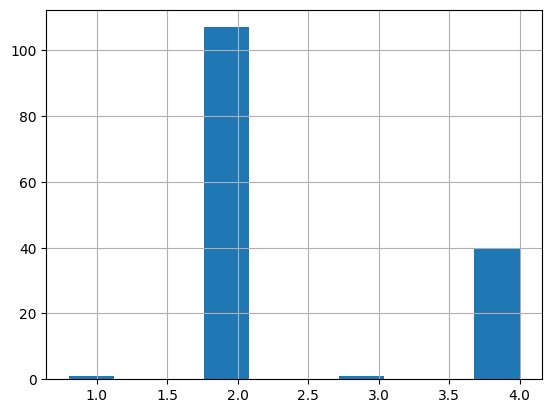

In [20]:
df['spacing'].hist()

In [19]:
df.to_excel("MetadatosISLES.xlsx")